In [3]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Parámetros fijos del sistema
L = 1.0       # Longitud de la barra
rho = 1.0     # Densidad del material
k = 1.0       # Constante elástica del resorte

# Casos de estudio: k*L/E in {10, 1.0, 0.1} -> E = k*L / (k*L/E)
casos = [
    {"label": "kL/E = 10 (Flexible)", "kL_E": 10.0, "E": 0.1,  "lambda": [1.42887, 4.3058, 7.22811]},
    {"label": "kL/E = 1.0 (Medio)",    "kL_E": 1.0,  "E": 1.0,  "lambda": [0.860334, 3.42562, 6.4373]},
    {"label": "kL/E = 0.1 (Rígido)",   "kL_E": 0.1,  "E": 10.0, "lambda": [0.311053, 3.1731, 6.2991]}
]

In [4]:
def calcular_alpha(lam):
    """Calcula la amplitud modal alpha_i por ortogonalidad (u0(x) = 1)."""
    return (2.0 * np.sin(lam)) / (lam + np.sin(lam) * np.cos(lam))

def u_xt(x, t, E_val, lams, alphas, n_modos=3):
    """Reconstruye el campo de desplazamientos u(x,t) por superposición modal."""
    c = np.sqrt(E_val / rho)
    u = np.zeros((len(x), len(t)))
    for i in range(n_modos):
        lam = lams[i]
        omega = lam * c / L
        phi = np.cos(lam * x / L)
        u += alphas[i] * np.outer(phi, np.cos(omega * t))
    return u

def sigma_xt(x, t, E_val, lams, alphas, n_modos=3):
    """Calcula el campo de esfuerzos axiales sigma(x,t) = E * du/dx."""
    c = np.sqrt(E_val / rho)
    sigma = np.zeros((len(x), len(t)))
    for i in range(n_modos):
        lam = lams[i]
        omega = lam * c / L
        # Derivada espacial: d(cos(lam*x/L))/dx = -(lam/L)*sin(lam*x/L)
        dphi_dx = -(lam / L) * np.sin(lam * x / L)
        sigma += E_val * alphas[i] * np.outer(dphi_dx, np.cos(omega * t))
    return sigma

In [5]:
resultados = []
x_grid = np.linspace(0, L, 200)

for c in casos:
    E_val = c["E"]
    lams = np.array(c["lambda"])
    alphas = np.array([calcular_alpha(lam) for lam in lams])

    # Frecuencia fundamental omega_1
    omega_1 = (lams[0] / L) * np.sqrt(E_val / rho)

    # Muestreo temporal adecuado: simular 3 periodos fundamentales completos
    T1 = 2.0 * np.pi / omega_1
    t_grid = np.linspace(0, 3 * T1, 1000)

    # Campos dinámicos
    u_field = u_xt(x_grid, t_grid, E_val, lams, alphas)
    sigma_field = sigma_xt(x_grid, t_grid, E_val, lams, alphas)

    # Deformación axial máxima: Delta u_max = max_t |u(0,t) - u(L,t)|
    delta_u_t = np.abs(u_field[0, :] - u_field[-1, :])
    delta_u_max = np.max(delta_u_t)

    # Esfuerzo máximo absoluto en toda la barra y tiempo
    sigma_max = np.max(np.abs(sigma_field))

    resultados.append({
        "Configuración": c["label"],
        "kL/E": c["kL_E"],
        "E": E_val,
        "omega_1 [rad/s]": omega_1,
        "alpha_1": alphas[0],
        "Delta u_max": delta_u_max,
        "sigma_max": sigma_max
    })

df_res = pd.DataFrame(resultados)
df_res

,Configuración,kL/E,E,omega_1 [rad/s],alpha_1,Delta u_max,sigma_max
0,kL/E = 10 (Flexible),10.0,0.1,0.451848,1.261963,1.271648,0.457368
1,kL/E = 1.0 (Medio),1.0,1.0,0.860334,1.119132,0.686476,1.117687
2,kL/E = 0.1 (Rígido),0.1,10.0,0.983636,1.016094,0.087968,1.480033


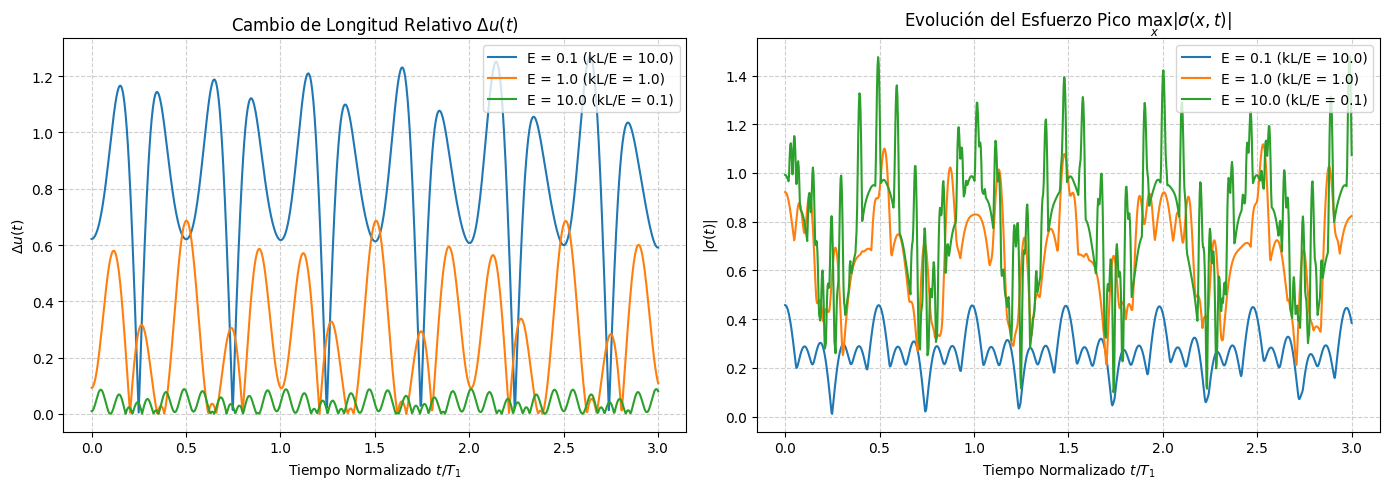

In [6]:
fig, axs = plt.subplots(1, 2, figsize=(14, 5))

for c in casos:
    E_val = c["E"]
    lams = np.array(c["lambda"])
    alphas = np.array([calcular_alpha(lam) for lam in lams])

    omega_1 = (lams[0] / L) * np.sqrt(E_val / rho)
    T1 = 2.0 * np.pi / omega_1
    t_grid = np.linspace(0, 3 * T1, 1000)

    u_field = u_xt(x_grid, t_grid, E_val, lams, alphas)
    sigma_field = sigma_xt(x_grid, t_grid, E_val, lams, alphas)

    # Delta u(t)
    delta_u_t = np.abs(u_field[0, :] - u_field[-1, :])
    axs[0].plot(t_grid / T1, delta_u_t, label=f"E = {E_val} (kL/E = {c['kL_E']})")

    # Esfuerzo máximo instantáneo a lo largo de la barra
    sigma_t_max = np.max(np.abs(sigma_field), axis=0)
    axs[1].plot(t_grid / T1, sigma_t_max, label=f"E = {E_val} (kL/E = {c['kL_E']})")

axs[0].set_title(r"Cambio de Longitud Relativo $\Delta u(t)$")
axs[0].set_xlabel(r"Tiempo Normalizado $t / T_1$")
axs[0].set_ylabel(r"$\Delta u(t)$")
axs[0].grid(True, linestyle="--", alpha=0.6)
axs[0].legend()

axs[1].set_title(r"Evolución del Esfuerzo Pico $\max_x |\sigma(x,t)|$")
axs[1].set_xlabel(r"Tiempo Normalizado $t / T_1$")
axs[1].set_ylabel(r"$|\sigma(t)|$")
axs[1].grid(True, linestyle="--", alpha=0.6)
axs[1].legend()

plt.tight_layout()
plt.show()